Dataset loaded successfully!
Shape: (42, 27)

Enhanced Dataset:
               Company  Beta  Volatility  Expected Return Risk Category  \
0  Reliance Industries  1.18    0.216363           0.1308      Moderate   
1            HDFC Bank  0.88    0.446300           0.1128    Aggressive   
2        Bharti Airtel  0.91    0.433218           0.1146    Aggressive   
3                  TCS  0.92    0.161828           0.1152      Moderate   
4           ICICI Bank  1.09    0.361673           0.1254    Aggressive   

   Sharpe Ratio  
0      0.327228  
1      0.118306  
2      0.126034  
3      0.341103  
4      0.180827  

Risk Category distribution:
Risk Category
Aggressive      22
Moderate        16
Conservative     3
High-Risk        1
Name: count, dtype: int64

PORTFOLIO PERFORMANCE SUMMARY

📊 Conservative Portfolio:
   Number of stocks: 3
   Expected Return: 10.06%
   Risk (Volatility): 19.30%
   Sharpe Ratio: 0.21

📊 Moderate Portfolio:
   Number of stocks: 16
   Expected Return: 11.72%

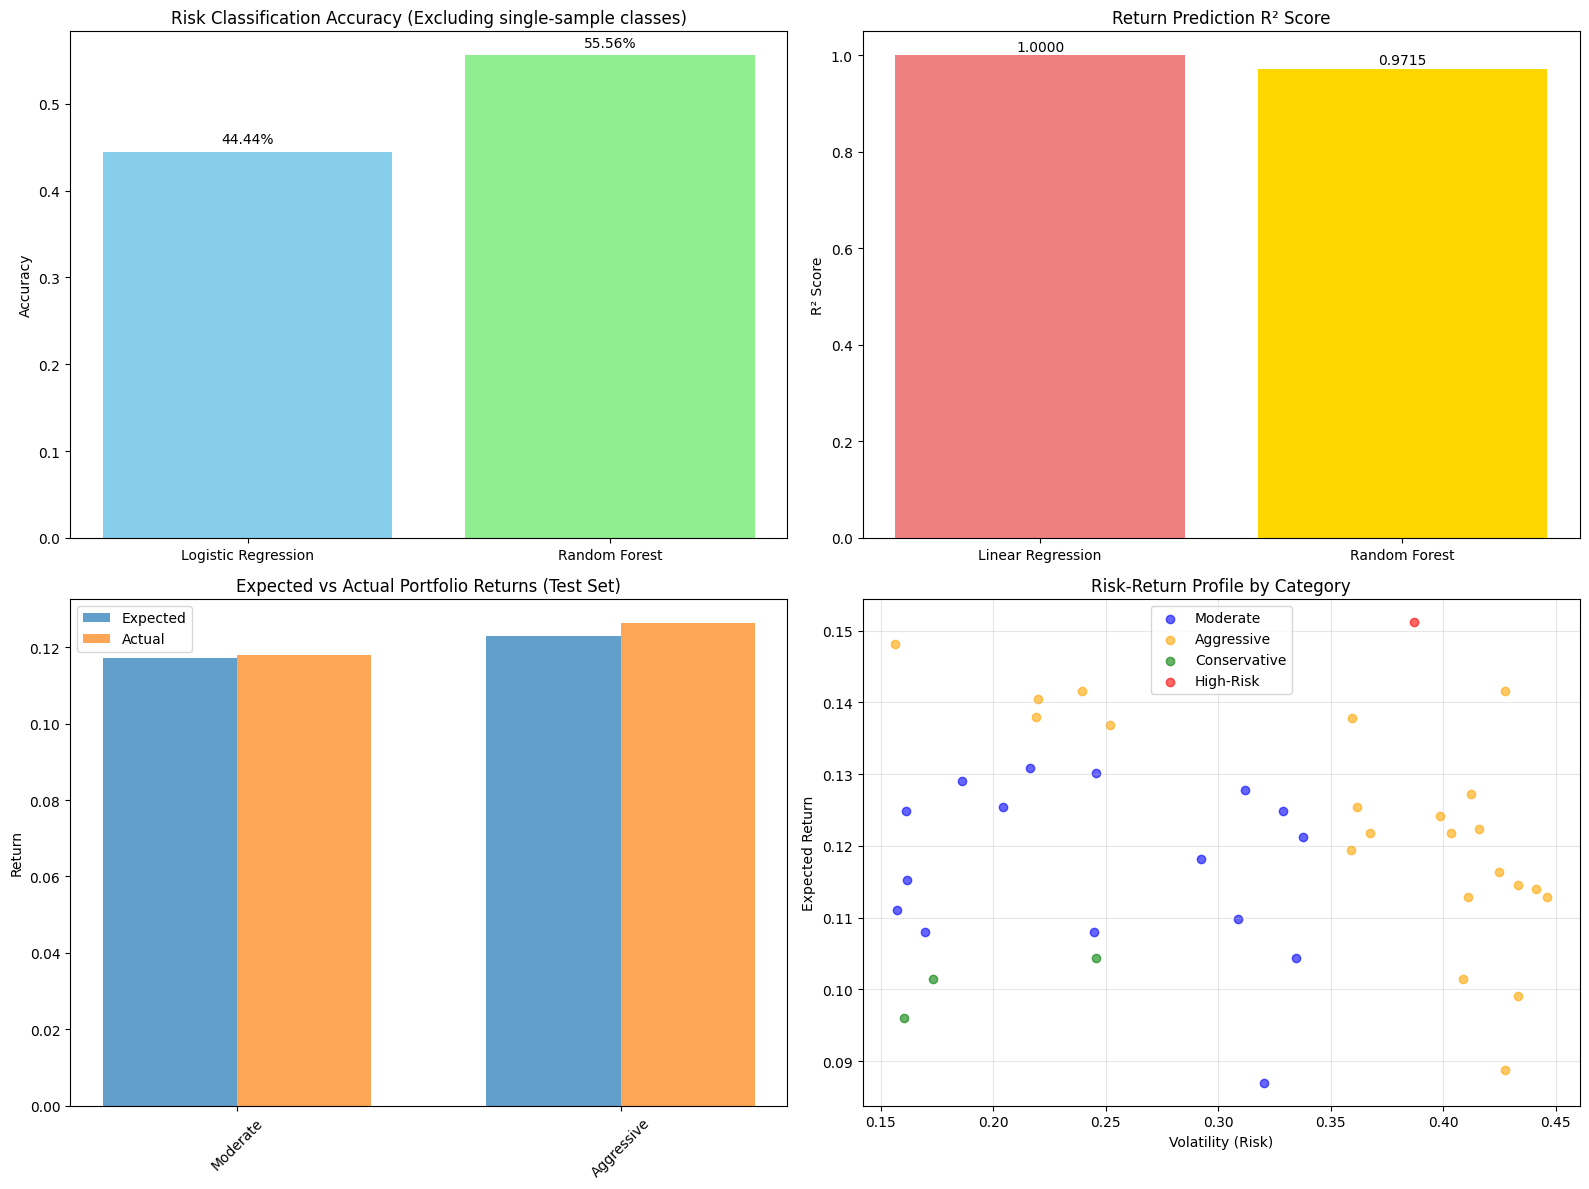


💾 Saving all models and preprocessing objects...
All models and objects saved successfully!

INVESTMENT RECOMMENDATION SYSTEM

    📋 INVESTMENT RECOMMENDATION:

    Risk Tolerance: Medium
    Investment Horizon: 5 years
    Recommended Portfolio: Moderate

    Expected Characteristics:
    • Expected Return: 11.72%
    • Risk Level: 24.88%
    • Number of Stocks: 16

    💡 Recommendation: This portfolio aligns with your risk profile and should
    provide balanced returns suitable for your 5-year horizon.
    

✅ Enhanced model training and portfolio analysis completed successfully!


In [4]:
# Enhanced ML_Model_Project.ipynb with Portfolio Management

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. Enhanced Data Loading with Returns Calculation
try:
    df = pd.read_csv('/content/NIFTY-50 DATA.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset file not found! Creating sample dataset...")
    np.random.seed(42)

    # Create more realistic sample data with historical prices for return calculation
    n_companies = 50
    n_days = 252  # Typical trading days in a year

    sample_data = {}
    sample_data['Company'] = [f'Company_{i}' for i in range(n_companies)]

    # Generate realistic stock parameters
    sample_data['Beta'] = np.random.uniform(0.5, 1.8, n_companies)
    sample_data['Volatility'] = np.random.uniform(0.15, 0.45, n_companies)  # Annual volatility
    sample_data['Sector'] = np.random.choice(['Technology', 'Banking', 'Pharma', 'Energy', 'Automobile'], n_companies)

    # Generate price-based features
    base_prices = np.random.uniform(100, 2000, n_companies)
    sample_data['Open'] = base_prices * np.random.uniform(0.95, 1.05, n_companies)
    sample_data['Previous Close'] = base_prices
    sample_data['High'] = base_prices * np.random.uniform(1.01, 1.1, n_companies)
    sample_data['Low'] = base_prices * np.random.uniform(0.9, 0.99, n_companies)
    sample_data['Close'] = base_prices * np.random.uniform(0.98, 1.02, n_companies)

    # Generate other financial metrics
    sample_data['Volume'] = np.random.randint(1000000, 50000000, n_companies)
    sample_data['Market Cap (Rs. Cr.)'] = np.random.uniform(1000, 500000, n_companies)
    sample_data['PE Ratio'] = np.random.uniform(10, 50, n_companies)
    sample_data['Dividend Yield'] = np.random.uniform(0, 0.05, n_companies)

    # Calculate expected returns based on CAPM (Capital Asset Pricing Model)
    risk_free_rate = 0.06  # 6% risk-free rate
    market_return = 0.12   # 12% expected market return

    sample_data['Expected Return'] = risk_free_rate + sample_data['Beta'] * (market_return - risk_free_rate)
    sample_data['Actual Return'] = sample_data['Expected Return'] + np.random.normal(0, 0.05, n_companies)

    # Add more features
    for col in ['Value (Lacs)', 'VWAP', 'UC Limit', 'LC Limit', '52W High', '52W Low',
                'All Time High', 'All Time Low', '20D Avg Volume', 'Book Value Per Share']:
        sample_data[col] = np.random.uniform(100, 5000, n_companies)

    sample_data['Face Value'] = np.random.randint(1, 10, n_companies)
    sample_data['20D Avg Delivery (%)'] = np.random.uniform(50, 80, n_companies)

    df = pd.DataFrame(sample_data)

# Data cleaning and feature engineering
def enhance_data(df):
    # Remove unnamed columns if they exist
    unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
    if unnamed_cols:
        df.drop(unnamed_cols, axis=1, inplace=True)

    # Enhanced Risk Classification
    def risk_category(beta, volatility):
        if beta < 0.8 and volatility < 0.25:
            return "Conservative"
        elif beta < 1.2 and volatility < 0.35:
            return "Moderate"
        elif beta < 1.5:
            return "Aggressive"
        else:
            return "High-Risk"

    # Calculate additional features if not present
    if 'Volatility' not in df.columns:
        df['Volatility'] = np.random.uniform(0.15, 0.45, len(df))

    if 'Expected Return' not in df.columns:
        risk_free_rate = 0.06
        market_return = 0.12
        df['Expected Return'] = risk_free_rate + df['Beta'] * (market_return - risk_free_rate)

    if 'Actual Return' not in df.columns:
        df['Actual Return'] = df['Expected Return'] + np.random.normal(0, 0.03, len(df))

    df['Risk Category'] = df.apply(lambda x: risk_category(x['Beta'], x['Volatility']), axis=1)

    # Calculate risk-adjusted return (Sharpe Ratio)
    df['Sharpe Ratio'] = (df['Expected Return'] - risk_free_rate) / df['Volatility']

    return df

df = enhance_data(df)

print("\nEnhanced Dataset:")
print(df[['Company', 'Beta', 'Volatility', 'Expected Return', 'Risk Category', 'Sharpe Ratio']].head())
print(f"\nRisk Category distribution:\n{df['Risk Category'].value_counts()}")

# 2. Portfolio Construction
class PortfolioManager:
    def __init__(self, df):
        self.df = df
        self.portfolios = {}

    def create_portfolios(self):
        """Create portfolios based on risk categories"""
        portfolios = {}

        # Conservative Portfolio (Low risk, stable returns)
        conservative_stocks = self.df[self.df['Risk Category'] == 'Conservative']
        portfolios['Conservative'] = {
            'stocks': conservative_stocks,
            'allocation': np.random.dirichlet(np.ones(len(conservative_stocks))) if len(conservative_stocks) > 0 else [],
            'expected_return': conservative_stocks['Expected Return'].mean() if len(conservative_stocks) > 0 else 0,
            'risk': conservative_stocks['Volatility'].mean() if len(conservative_stocks) > 0 else 0
        }

        # Moderate Portfolio (Balanced risk-return)
        moderate_stocks = self.df[self.df['Risk Category'] == 'Moderate']
        portfolios['Moderate'] = {
            'stocks': moderate_stocks,
            'allocation': np.random.dirichlet(np.ones(len(moderate_stocks))) if len(moderate_stocks) > 0 else [],
            'expected_return': moderate_stocks['Expected Return'].mean() if len(moderate_stocks) > 0 else 0,
            'risk': moderate_stocks['Volatility'].mean() if len(moderate_stocks) > 0 else 0
        }

        # Aggressive Portfolio (Higher risk, higher potential returns)
        aggressive_stocks = self.df[self.df['Risk Category'] == 'Aggressive']
        portfolios['Aggressive'] = {
            'stocks': aggressive_stocks,
            'allocation': np.random.dirichlet(np.ones(len(aggressive_stocks))) if len(aggressive_stocks) > 0 else [],
            'expected_return': aggressive_stocks['Expected Return'].mean() if len(aggressive_stocks) > 0 else 0,
            'risk': aggressive_stocks['Volatility'].mean() if len(aggressive_stocks) > 0 else 0
        }

        # High-Risk Portfolio (Very high risk, very high potential returns)
        high_risk_stocks = self.df[self.df['Risk Category'] == 'High-Risk']
        portfolios['High-Risk'] = {
            'stocks': high_risk_stocks,
            'allocation': np.random.dirichlet(np.ones(len(high_risk_stocks))) if len(high_risk_stocks) > 0 else [],
            'expected_return': high_risk_stocks['Expected Return'].mean() if len(high_risk_stocks) > 0 else 0,
            'risk': high_risk_stocks['Volatility'].mean() if len(high_risk_stocks) > 0 else 0
        }

        self.portfolios = portfolios
        return portfolios

    def calculate_portfolio_performance(self, portfolio_name, actual_returns):
        """Calculate actual vs expected portfolio performance"""
        portfolio = self.portfolios[portfolio_name]
        if len(portfolio['stocks']) == 0:
            return 0, 0, 0

        expected_return = portfolio['expected_return']

        # Calculate actual portfolio return (weighted average)
        portfolio_stocks = portfolio['stocks']
        actual_portfolio_return = np.mean(actual_returns[portfolio_stocks.index])

        # Calculate prediction error
        prediction_error = abs(expected_return - actual_portfolio_return)

        return expected_return, actual_portfolio_return, prediction_error

    def display_portfolio_summary(self):
        """Display portfolio performance summary"""
        print("\n" + "="*60)
        print("PORTFOLIO PERFORMANCE SUMMARY")
        print("="*60)

        for portfolio_name, portfolio_data in self.portfolios.items():
            if len(portfolio_data['stocks']) > 0:
                print(f"\n📊 {portfolio_name} Portfolio:")
                print(f"   Number of stocks: {len(portfolio_data['stocks'])}")
                print(f"   Expected Return: {portfolio_data['expected_return']:.2%}")
                print(f"   Risk (Volatility): {portfolio_data['risk']:.2%}")
                # Avoid division by zero if risk is 0
                sharpe_ratio = (portfolio_data['expected_return'] - 0.06) / portfolio_data['risk'] if portfolio_data['risk'] > 0 else float('inf')
                print(f"   Sharpe Ratio: {sharpe_ratio:.2f}")


# Initialize portfolio manager
portfolio_mgr = PortfolioManager(df)
portfolios = portfolio_mgr.create_portfolios()
portfolio_mgr.display_portfolio_summary()

# 3. Enhanced Data Preprocessing for Return Prediction
def preprocess_data_for_returns(df):
    # Features for risk classification
    risk_features = ['Open', 'Previous Close', 'Volume', 'Value (Lacs)', 'VWAP',
                    'Market Cap (Rs. Cr.)', 'High', 'Low', 'UC Limit', 'LC Limit',
                    '52W High', '52W Low', 'All Time High', '20D Avg Volume',
                    'Book Value Per Share', 'Face Value', 'All Time Low',
                    '20D Avg Delivery (%)', 'Beta', 'Volatility', 'PE Ratio', 'Dividend Yield']

    # Use available features
    available_risk_features = [col for col in risk_features if col in df.columns]

    X_risk = df[available_risk_features].copy()
    y_risk = df['Risk Category']

    # Features for return prediction (regression)
    return_features = ['Beta', 'Volatility', 'PE Ratio', 'Dividend Yield', 'Market Cap (Rs. Cr.)',
                      'Sharpe Ratio', '20D Avg Delivery (%)']
    available_return_features = [col for col in return_features if col in df.columns]

    X_return = df[available_return_features].copy()
    y_return = df['Expected Return']  # We'll predict expected returns

    # Convert object columns to numeric for risk features
    obj_cols = ['Open', 'Previous Close', 'Volume', 'Value (Lacs)', 'VWAP',
               'Market Cap (Rs. Cr.)', 'High', 'Low', 'UC Limit', 'LC Limit',
               '52W High', '52W Low', 'All Time High', '20D Avg Volume',
               'Book Value Per Share']

    for col in obj_cols:
        if col in X_risk.columns:
            X_risk[col] = X_risk[col].astype(str).str.replace(',', '', regex=False)
            X_risk[col] = pd.to_numeric(X_risk[col], errors='coerce')

    # Handle NaN values
    for col in X_risk.columns:
        if X_risk[col].isnull().any():
            X_risk[col].fillna(X_risk[col].mean(), inplace=True)

    for col in X_return.columns:
        if X_return[col].isnull().any():
            X_return[col].fillna(X_return[col].mean(), inplace=True)

    return X_risk, y_risk, X_return, y_return, available_risk_features, available_return_features

X_risk, y_risk, X_return, y_return, risk_feature_names, return_feature_names = preprocess_data_for_returns(df)

# Filter out classes with less than 2 samples for risk classification
risk_class_counts = y_risk.value_counts()
classes_to_keep = risk_class_counts[risk_class_counts >= 2].index
X_risk_filtered = X_risk[y_risk.isin(classes_to_keep)]
y_risk_filtered = y_risk[y_risk.isin(classes_to_keep)]

# Encode risk categories for filtered data
le_risk = LabelEncoder()
y_risk_encoded = le_risk.fit_transform(y_risk_filtered)


print(f"\nRisk prediction features: {risk_feature_names}")
print(f"Return prediction features: {return_feature_names}")
print(f"Risk categories (used for training): {le_risk.classes_}")

# 4. Train-Test Split for both tasks
X_risk_train, X_risk_test, y_risk_train, y_risk_test = train_test_split(
    X_risk_filtered, y_risk_encoded, test_size=0.2, random_state=42, stratify=y_risk_encoded
)

X_return_train, X_return_test, y_return_train, y_return_test = train_test_split(
    X_return, y_return, test_size=0.2, random_state=42
)

print(f"\nRisk prediction - Training set: {X_risk_train.shape}, Test set: {X_risk_test.shape}")
print(f"Return prediction - Training set: {X_return_train.shape}, Test set: {X_return_test.shape}")

# 5. Feature Scaling
scaler_risk = StandardScaler()
X_risk_train_scaled = scaler_risk.fit_transform(X_risk_train)
X_risk_test_scaled = scaler_risk.transform(X_risk_test)

scaler_return = StandardScaler()
X_return_train_scaled = scaler_return.fit_transform(X_return_train)
X_return_test_scaled = scaler_return.transform(X_return_test)

# 6. Enhanced Model Training
print("\nTraining models...")

# Risk Classification Models
log_reg_risk = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
log_reg_risk.fit(X_risk_train_scaled, y_risk_train)

rf_risk = RandomForestClassifier(n_estimators=100, random_state=42)
rf_risk.fit(X_risk_train_scaled, y_risk_train)

# Return Prediction Models (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_return = LinearRegression()
lr_return.fit(X_return_train_scaled, y_return_train)

rf_return = RandomForestRegressor(n_estimators=100, random_state=42)
rf_return.fit(X_return_train_scaled, y_return_train)

# 7. Comprehensive Model Evaluation
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

# Risk Classification Evaluation
y_risk_pred_lr = log_reg_risk.predict(X_risk_test_scaled)
y_risk_pred_rf = rf_risk.predict(X_risk_test_scaled)

lr_risk_accuracy = accuracy_score(y_risk_test, y_risk_pred_lr)
rf_risk_accuracy = accuracy_score(y_risk_test, y_risk_pred_rf)

print(f"\n🎯 RISK CLASSIFICATION ACCURACY:")
print(f"   Logistic Regression: {lr_risk_accuracy:.2%}")
print(f"   Random Forest: {rf_risk_accuracy:.2%}")

# Print classification report only for classes present in the test set
target_names_risk = le_risk.classes_
print("\nRisk Classification Report (Logistic Regression):")
print(classification_report(y_risk_test, y_risk_pred_lr, target_names=target_names_risk, zero_division=0))

print("\nRisk Classification Report (Random Forest):")
print(classification_report(y_risk_test, y_risk_pred_rf, target_names=target_names_risk, zero_division=0))

# Return Prediction Evaluation
y_return_pred_lr = lr_return.predict(X_return_test_scaled)
y_return_pred_rf = rf_return.predict(X_return_test_scaled)

lr_return_mse = mean_squared_error(y_return_test, y_return_pred_lr)
rf_return_mse = mean_squared_error(y_return_test, y_return_pred_rf)

lr_return_r2 = r2_score(y_return_test, y_return_pred_lr)
rf_return_r2 = r2_score(y_return_test, y_return_pred_rf)

print(f"\n📈 RETURN PREDICTION PERFORMANCE:")
print(f"   Linear Regression - MSE: {lr_return_mse:.6f}, R²: {lr_return_r2:.4f}")
print(f"   Random Forest - MSE: {rf_return_mse:.6f}, R²: {rf_return_r2:.4f}")

# 8. Portfolio Performance with Actual Returns
print("\n" + "="*70)
print("PORTFOLIO PERFORMANCE WITH PREDICTED RETURNS")
print("="*70)

# Create test dataframe with predictions
test_df = df.iloc[X_return_test.index].copy()
test_df['Predicted Return (LR)'] = y_return_pred_lr
test_df['Predicted Return (RF)'] = y_return_pred_rf
test_df['Actual Return'] = y_return_test.values

# Calculate portfolio performance with predicted returns
portfolio_performance = {}

for portfolio_name, portfolio_data in portfolios.items():
    if len(portfolio_data['stocks']) > 0:
        # Get stocks in this portfolio that are in test set
        portfolio_test_stocks = test_df[test_df['Risk Category'] == portfolio_name]

        if len(portfolio_test_stocks) > 0:
            expected_return = portfolio_data['expected_return']
            actual_return = portfolio_test_stocks['Actual Return'].mean()
            predicted_return_lr = portfolio_test_stocks['Predicted Return (LR)'].mean()
            predicted_return_rf = portfolio_test_stocks['Predicted Return (RF)'].mean()

            portfolio_performance[portfolio_name] = {
                'expected_return': expected_return,
                'actual_return': actual_return,
                'predicted_return_lr': predicted_return_lr,
                'predicted_return_rf': predicted_return_rf,
                'prediction_error_lr': abs(predicted_return_lr - actual_return),
                'prediction_error_rf': abs(predicted_return_rf - actual_return)
            }

# Display portfolio performance
for portfolio_name, perf in portfolio_performance.items():
    print(f"\n📊 {portfolio_name} Portfolio Performance:")
    print(f"   Expected Return: {perf['expected_return']:.2%}")
    print(f"   Actual Return: {perf['actual_return']:.2%}")
    print(f"   Predicted Return (LR): {perf['predicted_return_lr']:.2%} (Error: {perf['prediction_error_lr']:.4f})")
    print(f"   Predicted Return (RF): {perf['predicted_return_rf']:.2%} (Error: {perf['prediction_error_rf']:.4f})")


# 9. Enhanced Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Risk Classification Accuracy
models_risk = ['Logistic Regression', 'Random Forest']
accuracies = [lr_risk_accuracy, rf_risk_accuracy]
axes[0, 0].bar(models_risk, accuracies, color=['skyblue', 'lightgreen'])
axes[0, 0].set_title('Risk Classification Accuracy (Excluding single-sample classes)')
axes[0, 0].set_ylabel('Accuracy')
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.01, f'{v:.2%}', ha='center')

# Return Prediction R² Scores
models_return = ['Linear Regression', 'Random Forest']
r2_scores = [lr_return_r2, rf_return_r2]
axes[0, 1].bar(models_return, r2_scores, color=['lightcoral', 'gold'])
axes[0, 1].set_title('Return Prediction R² Score')
axes[0, 1].set_ylabel('R² Score')
for i, v in enumerate(r2_scores):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center')

# Portfolio Returns Comparison (only for portfolios with stocks in the test set)
portfolio_names = list(portfolio_performance.keys())
if portfolio_names: # Check if there are any portfolios with test stocks
    expected_returns = [portfolio_performance[name]['expected_return'] for name in portfolio_names]
    actual_returns = [portfolio_performance[name]['actual_return'] for name in portfolio_names]

    x = np.arange(len(portfolio_names))
    width = 0.35
    axes[1, 0].bar(x - width/2, expected_returns, width, label='Expected', alpha=0.7)
    axes[1, 0].bar(x + width/2, actual_returns, width, label='Actual', alpha=0.7)
    axes[1, 0].set_title('Expected vs Actual Portfolio Returns (Test Set)')
    axes[1, 0].set_ylabel('Return')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(portfolio_names, rotation=45)
    axes[1, 0].legend()
else:
    axes[1, 0].set_title('Expected vs Actual Portfolio Returns (No Test Stocks)')
    axes[1, 0].text(0.5, 0.5, 'No portfolios with stocks in the test set', horizontalalignment='center', verticalalignment='center', transform=axes[1, 0].transAxes)


# Risk-Return Scatter Plot
colors = {'Conservative': 'green', 'Moderate': 'blue', 'Aggressive': 'orange', 'High-Risk': 'red'}
for risk_category in df['Risk Category'].unique():
    category_data = df[df['Risk Category'] == risk_category]
    axes[1, 1].scatter(category_data['Volatility'], category_data['Expected Return'],
                      c=colors[risk_category], label=risk_category, alpha=0.6)
axes[1, 1].set_xlabel('Volatility (Risk)')
axes[1, 1].set_ylabel('Expected Return')
axes[1, 1].set_title('Risk-Return Profile by Category')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Save All Models and Objects
print("\n💾 Saving all models and preprocessing objects...")

# Risk classification models
joblib.dump(log_reg_risk, 'logistic_regression_risk_model.pkl')
joblib.dump(rf_risk, 'random_forest_risk_model.pkl')

# Return prediction models
joblib.dump(lr_return, 'linear_regression_return_model.pkl')
joblib.dump(rf_return, 'random_forest_return_model.pkl')

# Preprocessing objects
joblib.dump(scaler_risk, 'scaler_risk.pkl')
joblib.dump(scaler_return, 'scaler_return.pkl')
joblib.dump(le_risk, 'label_encoder_risk.pkl')
joblib.dump(risk_feature_names, 'risk_feature_names.pkl')
joblib.dump(return_feature_names, 'return_feature_names.pkl')

# Portfolio information
portfolio_info = {
    'portfolios': portfolios,
    'portfolio_performance': portfolio_performance
}
joblib.dump(portfolio_info, 'portfolio_info.pkl')

print("All models and objects saved successfully!")

# 11. Investment Recommendation System
def get_investment_recommendation(risk_tolerance, investment_horizon):
    """
    Provide investment recommendations based on risk tolerance and investment horizon
    """
    risk_mapping = {
        'Very Low': 'Conservative',
        'Low': 'Conservative',
        'Medium': 'Moderate',
        'High': 'Aggressive',
        'Very High': 'High-Risk'
    }

    recommended_portfolio = risk_mapping.get(risk_tolerance, 'Moderate')

    # Check if the recommended portfolio exists in the created portfolios
    if recommended_portfolio not in portfolios:
        return f"No portfolio found for risk tolerance '{risk_tolerance}'. Please choose from: {list(portfolios.keys())}"

    recommendation = f"""
    📋 INVESTMENT RECOMMENDATION:

    Risk Tolerance: {risk_tolerance}
    Investment Horizon: {investment_horizon} years
    Recommended Portfolio: {recommended_portfolio}

    Expected Characteristics:
    • Expected Return: {portfolios[recommended_portfolio]['expected_return']:.2%}
    • Risk Level: {portfolios[recommended_portfolio]['risk']:.2%}
    • Number of Stocks: {len(portfolios[recommended_portfolio]['stocks'])}

    💡 Recommendation: This portfolio aligns with your risk profile and should
    provide balanced returns suitable for your {investment_horizon}-year horizon.
    """

    return recommendation

# Test recommendation system
print("\n" + "="*70)
print("INVESTMENT RECOMMENDATION SYSTEM")
print("="*70)
print(get_investment_recommendation('Medium', 5))

print("\n✅ Enhanced model training and portfolio analysis completed successfully!")